# NB 05 — Distributed Modeling & Evaluation

**Phase 3 — Tasks 3.4 / 3.5  |  Phase 4 — Tasks 4.3 / 4.4**

1. Trains three Spark MLlib classifiers (3-fold CV each):
   - Baseline: Logistic Regression
   - Advanced A: Random Forest
   - Advanced B: Linear SVM
2. Evaluates all models on the held-out test set
3. Generates confusion matrices
4. Extracts Random Forest feature importances
5. Benchmarks scalability (throughput vs parallelism — Task 4.4)
6. Saves the best model for streaming

In [1]:
# ── Session bootstrap ─────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
SRC_DIR = PROJECT_ROOT / 'src'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/__init__.py is committed to the repo, no runtime touch needed
print('PROJECT_ROOT:', PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection


In [2]:
from src.utils import (
    create_spark_session, load_checkpoint, save_checkpoint,
    add_src_to_spark, Timer, checkpoint_exists, FIGURES_DIR, MODELS_DIR
)
from src.modeling import (
    train_baseline, train_random_forest, train_linear_svm,
    evaluate_model, confusion_matrix_spark, extract_feature_importances,
    save_model, load_model, benchmark_inference,
)
from src.feature_engineering import FEATURE_COLS
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns

spark = create_spark_session('ArabicAIDetection_Modeling')
add_src_to_spark(spark)


'/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/src_package.zip'

## 1. Load Phase 3 feature splits


In [3]:
PHASE3_FEATURE_DIR = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/data/processed/phase3_features')

TRAIN = PHASE3_FEATURE_DIR / 'phase3_train_features.csv'
VAL  = PHASE3_FEATURE_DIR / 'phase3_val_features.csv'
TEST  = PHASE3_FEATURE_DIR / 'phase3_test_features.csv'

TEXT_COL = 'text_clean'
LABEL_COL = 'label'
SEED = 42
TFIDF_FEATURES = 20_000
TFIDF_MIN_DF = 2

PHASE3_FEATURE_COLS = [
    'f001_total_chars',
    'f004_ws_over_C',
    'f013_hapax_ratio',
    'f022_entropy_wordfreq',
    'f025_single_quotes',
    'f034_total_sentences',
    'f043_num_nouns',
    'f046_num_adverbs',
    'f055_noun_to_verb_ratio',
    'f064_num_nominatives',
    'f067_num_singular',
    'f076_num_passive_sentences',
    'f085_sent_len_variance',
    'f088_sem_sim_sentences',
    'f097_bert_sim_tokens',
    'f106_tanween_freq',
    'f109_link_freq',
]

def normalize_csv_path(path_value):
    path = Path(path_value)
    if not path.exists():
        raise FileNotFoundError(f'CSV file not found: {path}')
    return path.resolve().as_posix()

TRAIN = normalize_csv_path(TRAIN)
VAL  = normalize_csv_path(VAL)
TEST  = normalize_csv_path(TEST)

print('TRAIN:', TRAIN)
print('VAL :', VAL)
print('TEST :', TEST)


TRAIN: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/data/processed/phase3_features/phase3_train_features.csv
VAL : /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/data/processed/phase3_features/phase3_val_features.csv
TEST : /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/data/processed/phase3_features/phase3_test_features.csv


In [5]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.pipeline import PipelineModel

def read_phase3_csv(path):
    return (
        spark.read
        .option('header', True)
        .option('inferSchema', False)
        .option('multiLine', True)
        .option('quote', '"')
        .option('escape', '"')
        .option('mode', 'PERMISSIVE')
        .csv(path)
    )

train_df = read_phase3_csv(TRAIN)
val_df   = read_phase3_csv(VAL)
test_df  = read_phase3_csv(TEST)

feature_cols = [c for c in PHASE3_FEATURE_COLS if c in train_df.columns]
missing_features = [c for c in PHASE3_FEATURE_COLS if c not in train_df.columns]
if missing_features:
    print('Skipped missing feature columns:', missing_features)

def prepare_split(df, split_name):
    result = df.withColumn(LABEL_COL, F.expr(f'try_cast(`{LABEL_COL}` as double)'))
    result = result.withColumn(TEXT_COL, F.coalesce(F.col(TEXT_COL).cast('string'), F.lit('')))
    for col_name in feature_cols:
        numeric_col = F.expr(f'try_cast(`{col_name}` as double)')
        result = result.withColumn(
            col_name,
            F.when(numeric_col.isNull() | F.isnan(numeric_col) | (numeric_col == float('inf')) | (numeric_col == float('-inf')), F.lit(0.0))
             .otherwise(numeric_col)
        )
    result = result.filter(F.col(LABEL_COL).isNotNull())
    return result.withColumn('split_name_modeling', F.lit(split_name))

train_df = prepare_split(train_df, 'train').cache()
val_df   = prepare_split(val_df, 'val').cache()
test_df  = prepare_split(test_df, 'test').cache()

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n = df.count()
    pos = df.filter(F.col(LABEL_COL) == 1).count()
    print(f'{name:5s}: {n:6,} rows  AI={pos/n*100:.1f}%')

print('Numeric feature count:', len(feature_cols))


Train: 29,355 rows  AI=80.0%
Val  :  6,290 rows  AI=80.0%
Test :  6,291 rows  AI=80.0%
Numeric feature count: 17


## 2. Build TF-IDF and assemble features


In [6]:
tfidf_pipeline = Pipeline(stages=[
    Tokenizer(inputCol=TEXT_COL, outputCol='_tokens'),
    HashingTF(inputCol='_tokens', outputCol='_tf_raw', numFeatures=TFIDF_FEATURES),
    IDF(inputCol='_tf_raw', outputCol='tfidf_features', minDocFreq=TFIDF_MIN_DF),
])

with Timer('TF-IDF fit on training split'):
    tfidf_model = tfidf_pipeline.fit(train_df)

train_tfidf = tfidf_model.transform(train_df)
val_tfidf   = tfidf_model.transform(val_df)
test_tfidf  = tfidf_model.transform(test_df)

assembler_inputs = feature_cols + ['tfidf_features']
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol='features',
    handleInvalid='keep',
)

train_ready = assembler.transform(train_tfidf).select(LABEL_COL, 'features', 'model_name', 'split_name_modeling').cache()
val_ready   = assembler.transform(val_tfidf).select(LABEL_COL, 'features', 'model_name', 'split_name_modeling').cache()
test_ready  = assembler.transform(test_tfidf).select(LABEL_COL, 'features', 'model_name', 'split_name_modeling').cache()

print('Final feature vector:', len(feature_cols), 'numeric features +', TFIDF_FEATURES, 'TF-IDF buckets')
print('features column present:', 'features' in train_ready.columns)


Final feature vector: 17 numeric features + 20000 TF-IDF buckets
features column present: True


## 3. Evaluation helpers


In [7]:
mc_eval = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol='prediction')

def evaluate_model_spark(model, data, model_name):
    preds = model.transform(data).cache()
    accuracy = mc_eval.evaluate(preds, {mc_eval.metricName: 'accuracy'})
    f1_weighted = mc_eval.evaluate(preds, {mc_eval.metricName: 'f1'})
    precision_weighted = mc_eval.evaluate(preds, {mc_eval.metricName: 'weightedPrecision'})
    recall_weighted = mc_eval.evaluate(preds, {mc_eval.metricName: 'weightedRecall'})

    counts_pdf = (
        preds.groupBy(F.col(LABEL_COL).alias('actual'), F.col('prediction').alias('predicted'))
        .count()
        .toPandas()
    )
    labels = sorted(set(counts_pdf['actual'].astype(int)).union(set(counts_pdf['predicted'].astype(int))))
    per_label = []
    for label_value in labels:
        tp = counts_pdf[(counts_pdf.actual == label_value) & (counts_pdf.predicted == label_value)]['count'].sum()
        fp = counts_pdf[(counts_pdf.actual != label_value) & (counts_pdf.predicted == label_value)]['count'].sum()
        fn = counts_pdf[(counts_pdf.actual == label_value) & (counts_pdf.predicted != label_value)]['count'].sum()
        precision_l = tp / (tp + fp) if (tp + fp) else 0.0
        recall_l = tp / (tp + fn) if (tp + fn) else 0.0
        f1_l = 2 * precision_l * recall_l / (precision_l + recall_l) if (precision_l + recall_l) else 0.0
        per_label.append((precision_l, recall_l, f1_l))

    precision_macro = float(np.mean([x[0] for x in per_label])) if per_label else 0.0
    recall_macro = float(np.mean([x[1] for x in per_label])) if per_label else 0.0
    f1_macro = float(np.mean([x[2] for x in per_label])) if per_label else 0.0

    roc_auc = 0.0
    try:
        roc_auc = BinaryClassificationEvaluator(
            labelCol=LABEL_COL, rawPredictionCol='rawPrediction', metricName='areaUnderROC'
        ).evaluate(preds)
    except Exception as exc:
        print(f'ROC-AUC not available for {model_name}: {exc}')

    metrics = {
        'model': model_name,
        'accuracy': round(accuracy, 4),
        'f1_macro': round(f1_macro, 4),
        'precision_macro': round(precision_macro, 4),
        'recall_macro': round(recall_macro, 4),
        'f1_weighted': round(f1_weighted, 4),
        'precision_weighted': round(precision_weighted, 4),
        'recall_weighted': round(recall_weighted, 4),
        'roc_auc': round(roc_auc, 4),
    }
    print(metrics)
    return metrics, preds

def fit_cv_model(model_name, estimator, grid):
    evaluator = MulticlassClassificationEvaluator(
        labelCol=LABEL_COL, predictionCol='prediction', metricName='f1'
    )
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=grid,
        evaluator=evaluator,
        numFolds=3,
        seed=SEED,
        parallelism=2,
    )
    with Timer(f'{model_name} cross-validation'):
        cv_model = cv.fit(train_ready)
    print(f'{model_name} best CV weighted-F1:', round(max(cv_model.avgMetrics), 4))
    return cv_model.bestModel, cv_model


## 4. Baseline — Logistic Regression


In [8]:
lr = LogisticRegression(
    featuresCol='features', labelCol=LABEL_COL,
    maxIter=200, family='binomial', standardization=True,
)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0])
    .build()
)

lr_model, lr_cv = fit_cv_model('Logistic Regression', lr, lr_grid)
lr_val_metrics, _ = evaluate_model_spark(lr_model, val_ready, 'LogisticRegression')


Logistic Regression best CV weighted-F1: 0.9699
{'model': 'LogisticRegression', 'accuracy': 0.9812, 'f1_macro': 0.9709, 'precision_macro': 0.9674, 'recall_macro': 0.9746, 'f1_weighted': 0.9813, 'precision_weighted': 0.9814, 'recall_weighted': 0.9812, 'roc_auc': 0.9965}


## 5. Advanced A — Random Forest


In [9]:
rf = RandomForestClassifier(
    featuresCol='features', labelCol=LABEL_COL,
    seed=SEED, featureSubsetStrategy='sqrt'
)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [100, 200])
    .addGrid(rf.maxDepth, [8, 12])
    .build()
)

rf_model, rf_cv = fit_cv_model('Random Forest', rf, rf_grid)
rf_val_metrics, _ = evaluate_model_spark(rf_model, val_ready, 'RandomForest')


Random Forest best CV weighted-F1: 0.7287
{'model': 'RandomForest', 'accuracy': 0.8094, 'f1_macro': 0.4929, 'precision_macro': 0.888, 'recall_macro': 0.524, 'f1_weighted': 0.7333, 'precision_weighted': 0.8399, 'recall_weighted': 0.8094, 'roc_auc': 0.9935}


## 6. Advanced B — Linear SVM


In [10]:
svm = LinearSVC(
    featuresCol='features', labelCol=LABEL_COL,
    maxIter=100, standardization=True,
)
svm_grid = (
    ParamGridBuilder()
    .addGrid(svm.regParam, [0.01, 0.1, 1.0])
    .build()
)

svm_model, svm_cv = fit_cv_model('Linear SVM', svm, svm_grid)
svm_val_metrics, _ = evaluate_model_spark(svm_model, val_ready, 'LinearSVM')


Linear SVM best CV weighted-F1: 0.9675
{'model': 'LinearSVM', 'accuracy': 0.979, 'f1_macro': 0.9678, 'precision_macro': 0.9595, 'recall_macro': 0.9767, 'f1_weighted': 0.9792, 'precision_weighted': 0.9797, 'recall_weighted': 0.979, 'roc_auc': 0.9952}


## 7. Validation comparison — select best model



── Validation set results ──
             model  accuracy  f1_macro  precision_macro  recall_macro  f1_weighted  precision_weighted  recall_weighted  roc_auc
LogisticRegression    0.9812    0.9709           0.9674        0.9746       0.9813              0.9814           0.9812   0.9965
         LinearSVM    0.9790    0.9678           0.9595        0.9767       0.9792              0.9797           0.9790   0.9952
      RandomForest    0.8094    0.4929           0.8880        0.5240       0.7333              0.8399           0.8094   0.9935


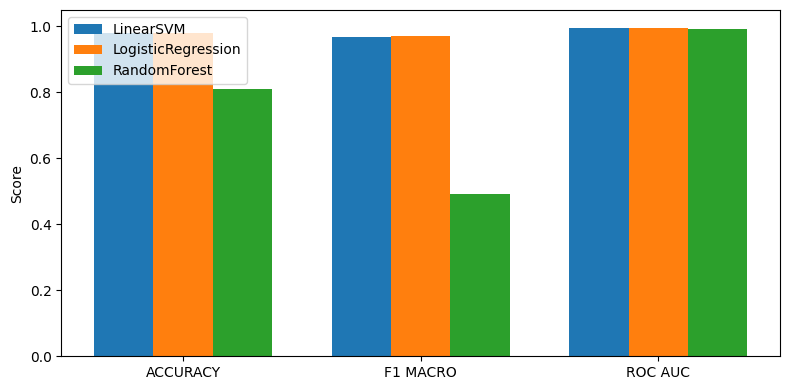

Best model by validation macro-F1: LogisticRegression


In [11]:
val_results = pd.DataFrame([lr_val_metrics, rf_val_metrics, svm_val_metrics]).sort_values('f1_macro', ascending=False)
print('\n── Validation set results ──')
print(val_results.to_string(index=False))

metrics_to_plot = ['accuracy', 'f1_macro', 'roc_auc']
x, width = np.arange(len(metrics_to_plot)), 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, row in enumerate(val_results.sort_values('model').to_dict('records')):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=row['model'])
ax.set_xticks(x + width)
ax.set_xticklabels([m.replace('_', ' ').upper() for m in metrics_to_plot])
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'model_comparison_val.png'), dpi=150)
plt.show()

best_val_name = val_results.iloc[0]['model']
model_lookup = {
    'LogisticRegression': lr_model,
    'RandomForest': rf_model,
    'LinearSVM': svm_model,
}
best_model = model_lookup[best_val_name]
print('Best model by validation macro-F1:', best_val_name)


## 8. Final evaluation on held-out test set


In [12]:
model_pairs = [
    ('LogisticRegression', lr_model),
    ('RandomForest', rf_model),
    ('LinearSVM', svm_model),
]

test_rows = []
test_predictions = {}
print('Evaluating all models on held-out test set ...')
for name, model in model_pairs:
    metrics, preds = evaluate_model_spark(model, test_ready, name)
    test_rows.append(metrics)
    test_predictions[name] = preds

test_results = pd.DataFrame(test_rows).sort_values('f1_macro', ascending=False)
print('\n── TEST SET RESULTS ──')
print(test_results.to_string(index=False))

test_results.to_csv(str(FIGURES_DIR / 'test_metrics.csv'), index=False)
print('Saved:', FIGURES_DIR / 'test_metrics.csv')


Evaluating all models on held-out test set ...
{'model': 'LogisticRegression', 'accuracy': 0.9824, 'f1_macro': 0.9726, 'precision_macro': 0.9692, 'recall_macro': 0.9762, 'f1_weighted': 0.9824, 'precision_weighted': 0.9825, 'recall_weighted': 0.9824, 'roc_auc': 0.9966}
{'model': 'RandomForest', 'accuracy': 0.8094, 'f1_macro': 0.4916, 'precision_macro': 0.9038, 'recall_macro': 0.5234, 'f1_weighted': 0.7328, 'precision_weighted': 0.8461, 'recall_weighted': 0.8094, 'roc_auc': 0.9944}
{'model': 'LinearSVM', 'accuracy': 0.98, 'f1_macro': 0.9693, 'precision_macro': 0.9605, 'recall_macro': 0.9788, 'f1_weighted': 0.9802, 'precision_weighted': 0.9807, 'recall_weighted': 0.98, 'roc_auc': 0.9945}

── TEST SET RESULTS ──
             model  accuracy  f1_macro  precision_macro  recall_macro  f1_weighted  precision_weighted  recall_weighted  roc_auc
LogisticRegression    0.9824    0.9726           0.9692        0.9762       0.9824              0.9825           0.9824   0.9966
         LinearSVM    0.

## 9. Confusion matrices


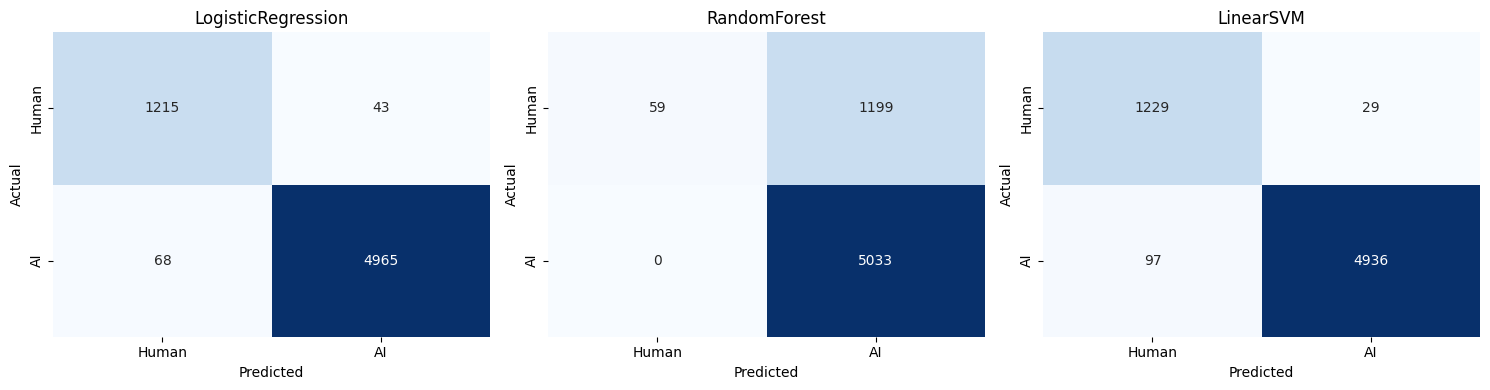

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, model_pairs):
    cm_df = (
        model.transform(test_ready)
        .groupBy(F.col(LABEL_COL).alias('actual'), F.col('prediction').alias('predicted'))
        .count()
        .toPandas()
    )
    cm = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        cm[int(row['actual']), int(row['predicted'])] = int(row['count'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'confusion_matrices.png'), dpi=150)
plt.show()


## 10. Random Forest feature importances


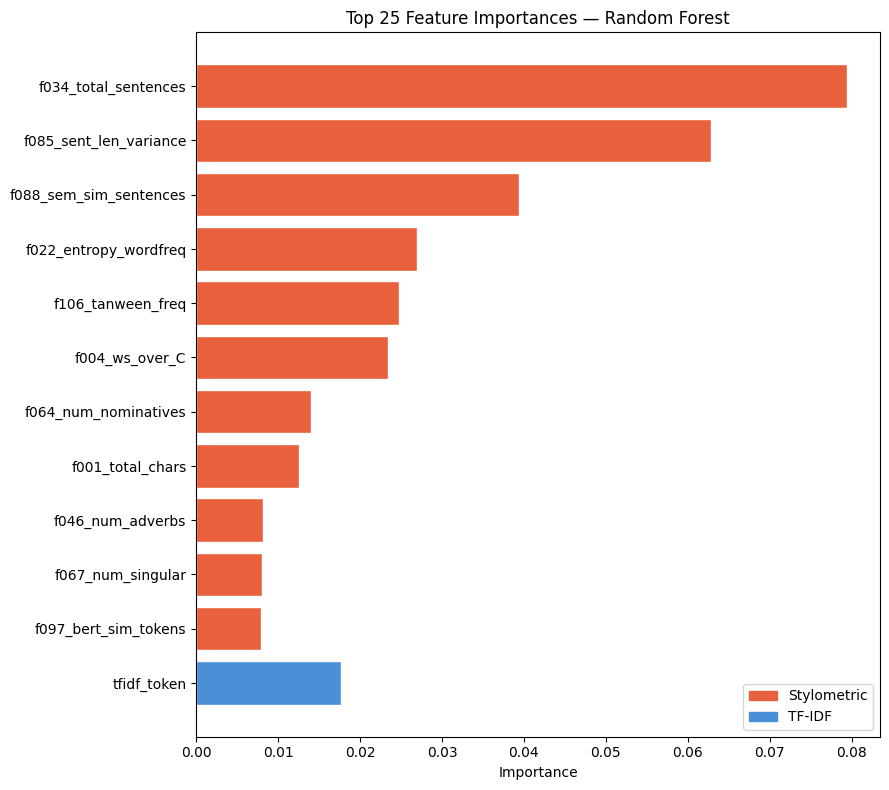

               feature  importance
  f034_total_sentences    0.079501
f085_sent_len_variance    0.062863
f088_sem_sim_sentences    0.039441
 f022_entropy_wordfreq    0.026900
     f106_tanween_freq    0.024783
        f004_ws_over_C    0.023421
           tfidf_11299    0.017669
           tfidf_14759    0.017157
  f064_num_nominatives    0.014057
           tfidf_16808    0.013872
            tfidf_1740    0.012801
      f001_total_chars    0.012505
            tfidf_8599    0.011125
           tfidf_18558    0.010440
           tfidf_17868    0.009998
            tfidf_2526    0.009121
            tfidf_4521    0.008337
      f046_num_adverbs    0.008211
     f067_num_singular    0.008042
             tfidf_435    0.007939
  f097_bert_sim_tokens    0.007920
           tfidf_17273    0.007770
           tfidf_19958    0.007529
            tfidf_9138    0.007282
            tfidf_7536    0.007005


In [14]:
rf_feature_names = feature_cols + [f'tfidf_{i}' for i in range(TFIDF_FEATURES)]
rf_importances = rf_model.featureImportances.toArray()
imp_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances,
}).sort_values('importance', ascending=False).head(25)

plot_df = imp_df.copy()
plot_df['display_feature'] = plot_df['feature'].apply(lambda x: x if not x.startswith('tfidf_') else 'tfidf_token')

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#E8603C' if not f.startswith('tfidf_') else '#4A90D9' for f in plot_df['feature']]
ax.barh(plot_df['display_feature'][::-1], plot_df['importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Top 25 Feature Importances — Random Forest')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E8603C', label='Stylometric'), Patch(color='#4A90D9', label='TF-IDF')])
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'feature_importances.png'), dpi=150)
plt.show()

print(imp_df.to_string(index=False))


## 11. Scalability benchmark


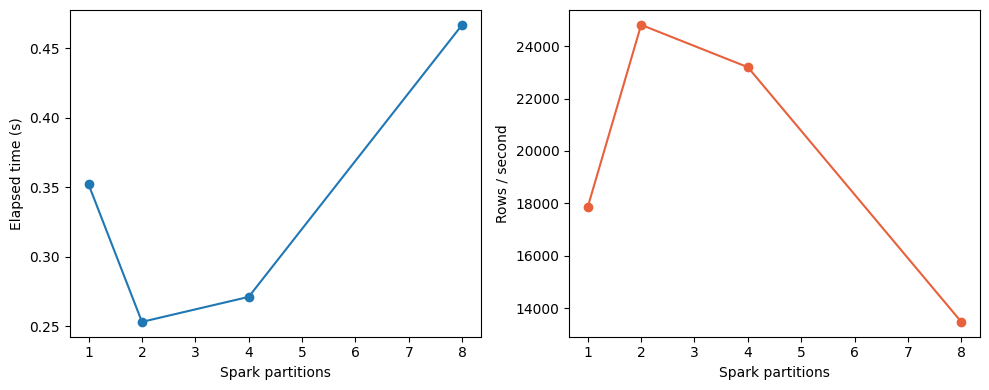

Saved: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/reports/figures/scalability_benchmark.csv
 partitions  rows  elapsed_s  rows_per_s
          1  6291      0.352    17860.90
          2  6291      0.253    24818.07
          4  6291      0.271    23200.05
          8  6291      0.467    13470.72


In [15]:
import time

partition_levels = [1, 2, 4, 8]
benchmark_rows = []
for n_parts in partition_levels:
    df_part = test_ready.repartition(n_parts).cache()
    df_part.count()
    t0 = time.perf_counter()
    pred_count = best_model.transform(df_part).count()
    elapsed = time.perf_counter() - t0
    benchmark_rows.append({
        'partitions': n_parts,
        'rows': pred_count,
        'elapsed_s': round(elapsed, 3),
        'rows_per_s': round(pred_count / elapsed, 2) if elapsed > 0 else 0,
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.to_csv(str(FIGURES_DIR / 'scalability_benchmark.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(benchmark_df['partitions'], benchmark_df['elapsed_s'], marker='o')
axes[0].set_xlabel('Spark partitions')
axes[0].set_ylabel('Elapsed time (s)')
axes[1].plot(benchmark_df['partitions'], benchmark_df['rows_per_s'], marker='o', color='#E8603C')
axes[1].set_xlabel('Spark partitions')
axes[1].set_ylabel('Rows / second')
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'scalability_benchmark.png'), dpi=150)
plt.show()

print('Saved:', FIGURES_DIR / 'scalability_benchmark.csv')
print(benchmark_df.to_string(index=False))


## 12. Save best model for streaming


In [16]:
model_dir = MODELS_DIR / 'best_model'
tfidf_dir = MODELS_DIR / 'tfidf_pipeline'
full_pipeline_dir = MODELS_DIR / 'full_inference_pipeline'

# Classifier-only model for the assembled feature vector.
best_model.write().overwrite().save(str(model_dir))

# Text vectorizer for reuse in batch or streaming inference.
tfidf_model.write().overwrite().save(str(tfidf_dir))

# Full inference pipeline: text_clean -> TF-IDF -> features -> prediction.
full_pipeline = PipelineModel(stages=tfidf_model.stages + [assembler, best_model])
full_pipeline.write().overwrite().save(str(full_pipeline_dir))

pd.Series(assembler_inputs).to_csv(str(FIGURES_DIR / 'feature_order.csv'), index=False, header=['feature'])

print('Best model:', best_val_name)
print('Saved classifier:', model_dir)
print('Saved TF-IDF pipeline:', tfidf_dir)
print('Saved full inference pipeline:', full_pipeline_dir)
print('Saved feature order:', FIGURES_DIR / 'feature_order.csv')


Best model: LogisticRegression
Saved classifier: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/models/best_model
Saved TF-IDF pipeline: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/models/tfidf_pipeline
Saved full inference pipeline: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/models/full_inference_pipeline
Saved feature order: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/reports/figures/feature_order.csv
